# Posterior-mean prior: recovering a denoiser's regularizer from the denoiser alone

The other notebooks here learn a prior the paper already knows in closed form, using two networks. This
one learns a prior with **no closed form in its own argument**, using **one network and nothing but
evaluations of a denoiser**.

## The object

Smooth the sparsity prior $J = \lambda\|\cdot\|_1$ by the Cole--Hopf (viscous) solution $S_\varepsilon$ at level
$\varepsilon$. The **posterior-mean denoiser** is then $u_{PM} = \mathbf{x} - t\nabla S_\varepsilon = \nabla K_\varepsilon$ with
$K_\varepsilon = \tfrac12\|\mathbf{x}\|^2 - tS_\varepsilon$ strictly convex, and by Darbon--Langlois (JMIV) Prop. 3.2 it
is the proximal map of a $C^2$ regularizer

$$f_{reg} = K_\varepsilon^{*} - \tfrac12\|\cdot\|^2 ,$$

which is what we recover. Under $S \leftarrow S_\varepsilon$, $\psi \leftarrow K_\varepsilon$, $J_{BVS} \leftarrow f_{reg}$
this is an instance of the paper's own first-order theory --- no new theorems --- with an imaging meaning
for every object. Design: `CLAUDE/_reviews/work2.tex`, Instantiation A.

The choice of $u_{PM}$ is not cosmetic. The theory needs the denoiser to *be* $\nabla$ of a convex
potential; a generic trained denoiser (DnCNN, BM3D) is not even a conservative field. The posterior-mean
denoiser is the class where that hypothesis is a **theorem**, so "the prox is known" is literally true.

## Why one network, and no value function

**We assume $S_\varepsilon(\mathbf{x}_k,t)$ is never observed.** That is the realistic regime: $S_\varepsilon$ is a
log-partition function (thermodynamic integration, for a sampler), while the denoiser is one forward
pass. What one call gives us is exact gradient data, because prox optimality $0 = \mathbf{y} - \mathbf{x} +
\nabla f_{reg}(\mathbf{y})$ says

$$\boxed{\;\nabla f_{reg}(\mathbf{y}_k) = \mathbf{x}_k - \mathbf{y}_k \quad\text{at}\quad \mathbf{y}_k = u_{PM}(\mathbf{x}_k).\;}$$

No network stands between the data and this target, so we fit $f_{reg}$ directly with one convex net and
never form $\psi_\theta$, never invert, never conjugate. The paper's own sampling model
(`sections/3_main-results.tex:119`) already assumes the gradient is observed; here it is the *only* thing
observed.

**The constant is unidentifiable, and that is fine.** Gradients fix $f_{reg}$ only up to an additive
constant, and nothing in the data pins it. Nothing needs to: $\mathrm{prox}_{f+c} = \mathrm{prox}_f$, so
the constant is invisible to the object a prior exists to define. All errors below are therefore reported
with the best constant removed --- one scalar of oracle information, granted once and stated plainly.

## Protocol

Standalone by necessity, not by preference: this tests a *different data model* from the four production
families, so there is no `bin/` config to wrap and the training loop lives here. Only the ground truth is
imported (`src.targets.PosteriorMeanL1`), pinned by `tests/test_posterior_mean_l1.py` --- a target bug is
the one error nothing downstream could catch.

**$S_\varepsilon$ appears exactly once below: to compute the ground truth we score against.** It never touches
training. The boundary is marked in the code.

**These are not production numbers.** $\varepsilon = 0.1$, $t = 1$, $\lambda = 1$, $n = 8$ throughout.

| | here | D2 production |
|---|---|---|
| $N$ | 20,000 | $15{,}000\cdot n$ |
| width | 128 | 256 |
| steps | 50,000 | 250,000 |

Unchanged from D2: 2 layers, Softplus $\beta=5$, `wclip()` every step, Adam, batch 512, lr $10^{-3}$ decayed
$\times0.1$ at 50%/75%, no early stopping, best-validation checkpoint, CPU, and the boxes --- $\mathbf{x}_k$ on
$[-A,A]^n$ with $A = a + t\lambda = 5$, the smallest half-width whose image under $u_{PM}$ covers the query
box $[-4,4]^n$ (onto, with zero margin, exactly as for `QuadraticL1`).

At $\varepsilon = 0.1$ the smoothing length is $\sqrt{2t\varepsilon}\approx0.45$ against a threshold $t\lambda = 1$, and
$f_{reg}''(0)\sim1/\varepsilon$. As $\varepsilon\to0$ the family becomes exactly the `quadratic_l1` notebook's nonsmooth
$\|\cdot\|_1$ (verified to 1 ulp): a homotopy of a family already in the paper, not a new one.

In [1]:
import os
import sys
import time

import numpy as np
import torch

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))  # numerics/
assert os.path.isdir(os.path.join(ROOT, "src")), "run this notebook from numerics/notebooks/"
sys.path.insert(0, ROOT)

from src.network import LPN
from src.targets import PosteriorMeanL1   # ground truth; pinned by tests/test_posterior_mean_l1.py

# AFTER the src imports: src/__init__.py pulls in src.plotting, which calls
# matplotlib.use("Agg") at import time so bin/ can render headless. Selecting the
# backend before this point silently loses every figure.
%matplotlib inline
import matplotlib.pyplot as plt

DIM, EPS, A = 8, 0.1, 4.0          # query box [-A,A]^n is where the prior is scored
N, WIDTH, STEPS = 20_000, 128, 50_000       # scoping budget; see the protocol table
LAYERS, BETA, BATCH, LR = 2, 5, 512, 1e-3
N_EVAL = 1000

problem = PosteriorMeanL1(eps=EPS, lam=1.0, t=1.0)
A_TRAIN = problem.train_halfwidth(A)        # = a + t*lam = 5
torch.manual_seed(1)
print(f"n={DIM}, eps={EPS}, sample box +-{A_TRAIN}, query box +-{A}, "
      f"N={N}, width={WIDTH}, steps={STEPS}")

n=8, eps=0.1, sample box +-5.0, query box +-4.0, N=20000, width=128, steps=50000


## The data

Everything the method sees: a point, one denoiser call, and the difference between them.

The induced density is the one thing we do not choose. Uniform $\mathbf{x}_k$ makes $\mathbf{y}_k =
\nabla\psi(\mathbf{x}_k)$ **non-uniform**, with density $\propto 1/\det\nabla^2\psi$ --- piled up near the
origin, where $f_{reg}$ is most curved. That is avenue E.4's curvature-weighted sampling arriving
unbidden, and it is forced: placing a sample at a chosen $\mathbf{y}$ would mean inverting the denoiser,
which is the thing this design exists to avoid.

In [2]:
def denoiser_data(dim, n, seed, a_train):
    """All the method ever sees. One denoiser call per point; no value function."""
    x = np.random.default_rng(seed).uniform(-a_train, a_train, (n, dim))
    y = problem.denoiser(x)              # the ONE forward pass we are allowed
    return {"x": x, "y": y, "g": x - y}  # grad f_reg(y_k) = x_k - y_k  (prox optimality)

tr = denoiser_data(DIM, N, seed=1, a_train=A_TRAIN)
va = denoiser_data(DIM, 4000, seed=2, a_train=A_TRAIN)

# ---- GROUND TRUTH: everything below this line is for SCORING ONLY. It uses S_eps
# ---- (via psi inside prior_true) and a root-find, neither of which training may see.
y_eval = np.random.default_rng(3).uniform(-A, A, (4000, DIM))[:N_EVAL]
freg_eval = problem.prior_true(y_eval)
scale = float(np.mean(np.abs(freg_eval)))   # |J| ~ n, so errors are reported RELATIVE
# ---- end ground truth -------------------------------------------------------

x_cert = np.random.default_rng(4).uniform(-A_TRAIN, A_TRAIN, (1000, DIM))  # certificate pts
reach = np.max(np.abs(tr["y"]))
print(f"y_k reach |y|_inf = {reach:.4f} (query box needs {A});  "
      f"eval points beyond it: {100*np.mean(np.max(np.abs(y_eval), axis=1) > reach):.2f}%")
print(f"mean|f_reg| on the eval set = {scale:.4f}")

y_k reach |y|_inf = 4.0000 (query box needs 4.0);  eval points beyond it: 0.00%
mean|f_reg| on the eval set = 16.1594


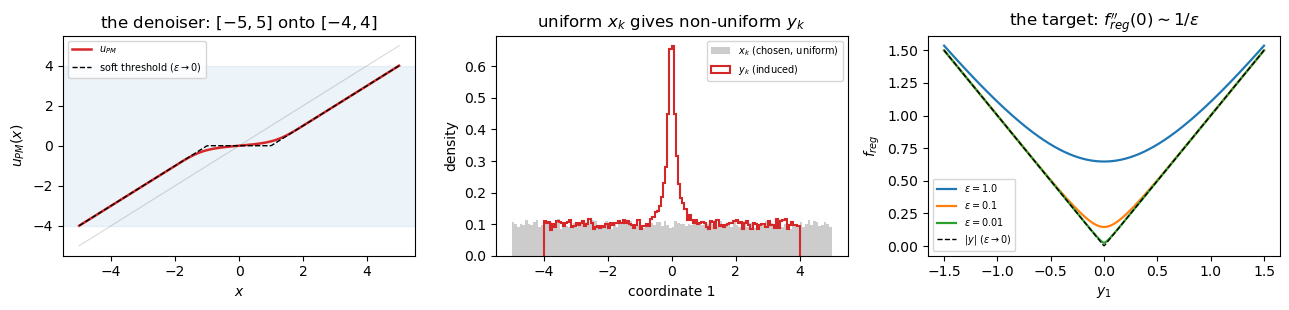

density ratio, origin vs tail: 2.1x


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
g = np.linspace(-A_TRAIN, A_TRAIN, 400).reshape(-1, 1)
ax[0].plot(g, problem.denoiser(g), color="C3", lw=1.8, label="$u_{PM}$")
ax[0].plot(g, np.sign(g) * np.maximum(np.abs(g) - 1, 0), "k--", lw=1,
           label="soft threshold ($\\varepsilon\\to0$)")
ax[0].plot(g, g, color="0.85", lw=0.8, zorder=0)
ax[0].axhspan(-A, A, color="C0", alpha=0.08)
ax[0].set_xlabel("$x$"); ax[0].set_ylabel("$u_{PM}(x)$"); ax[0].legend(fontsize=7)
ax[0].set_title(f"the denoiser: $[-{A_TRAIN:g},{A_TRAIN:g}]$ onto $[-{A:g},{A:g}]$")

ax[1].hist(tr["x"][:, 0], bins=120, density=True, color="0.8", label="$x_k$ (chosen, uniform)")
ax[1].hist(tr["y"][:, 0], bins=120, density=True, histtype="step", color="C3", lw=1.5,
           label="$y_k$ (induced)")
ax[1].set_xlabel("coordinate 1"); ax[1].set_ylabel("density"); ax[1].legend(fontsize=7)
ax[1].set_title("uniform $x_k$ gives non-uniform $y_k$")

gg = np.linspace(-1.5, 1.5, 600).reshape(-1, 1)
for e_ in (1.0, 0.1, 0.01):
    ax[2].plot(gg, PosteriorMeanL1(eps=e_).prior_true(gg), lw=1.6, label=f"$\\varepsilon={e_}$")
ax[2].plot(gg, np.abs(gg), "k--", lw=1, label=r"$|y|$ ($\varepsilon\to0$)")
ax[2].set_xlabel("$y_1$"); ax[2].set_ylabel("$f_{reg}$"); ax[2].legend(fontsize=7)
ax[2].set_title(r"the target: $f_{reg}''(0)\sim1/\varepsilon$")
fig.tight_layout(); plt.show()

print(f"density ratio, origin vs tail: "
      f"{np.mean(np.abs(tr['y'][:, 0]) < 0.25) / np.mean(np.abs(tr['y'][:, 0]) > 3.5):.1f}x")

## Training

One convex net, one loss: $\;\mathcal{L} = \mathrm{MSE}\big(\nabla J_\theta(\mathbf{y}_k),\, \mathbf{x}_k -
\mathbf{y}_k\big)$. The input-gradient enters the loss, so it is built with `create_graph=True` and then
differentiated w.r.t. the parameters (`LPN.forward` already supports this). Each sample supplies $n$
constraints rather than the $1$ a value-loss would.

Everything else mirrors `src.train.train_potential` --- same Adam, fractional decay, `wclip()` after every
step, best-validation restore --- so the loss is the only difference.

In [4]:
def train_grad(model, X, G, Xv, Gv, batch_size=BATCH, steps=STEPS, lr=LR,
               lr_decay_at=(0.5, 0.75), eval_every=500, seed=1):
    """Fit a convex net to observed gradients: loss = MSE(grad net(y_k), G) / var(G).

    Normalized by the target variance so the loss reads the same at any scale.
    Returns the usual history; the model returned is the best-validation one.
    """
    dev = next(model.parameters()).device
    t_ = lambda a: torch.tensor(np.asarray(a)).float().to(dev)
    X, Xv, G, Gv = t_(X), t_(Xv), t_(G), t_(Gv)
    s = float(G.var().item())
    n = X.shape[0]

    def loss_at(xb, gb, create_graph):
        xin = xb.detach().requires_grad_(True)
        grad = torch.autograd.grad(model.scalar(xin).sum(), xin, create_graph=create_graph)[0]
        return (grad - gb).pow(2).mean() / s

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    decay = {int(f * steps) for f in lr_decay_at}
    gen = torch.Generator(device="cpu").manual_seed(seed)
    hist = {"train": [], "val": [], "steps": [], "best_val": None}
    best, best_state = np.inf, None
    step, running, seen = 0, 0.0, 0
    perm, cursor = torch.randperm(n, generator=gen).to(dev), 0

    while step < steps:
        if cursor + batch_size > n:                       # reshuffle on epoch exhaustion
            perm, cursor = torch.randperm(n, generator=gen).to(dev), 0
        idx = perm[cursor:cursor + batch_size]
        cursor += batch_size
        if step in decay and step > 0:
            for gp in opt.param_groups:
                gp["lr"] *= 0.1

        opt.zero_grad()
        loss = loss_at(X[idx], G[idx], create_graph=True)  # double backprop
        loss.backward()
        opt.step()
        model.wclip()                                      # convexity, every step
        running += loss.item() * idx.shape[0]
        seen += idx.shape[0]
        step += 1

        if step % eval_every == 0:
            vl = loss_at(Xv, Gv, create_graph=False).item()
            hist["train"].append(running / seen); hist["val"].append(vl)
            hist["steps"].append(step); running, seen = 0.0, 0
            if vl < best - 1e-12:
                best = vl
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        hist["best_val"] = float(best)
    return hist


torch.manual_seed(1)
model = LPN(in_dim=DIM, hidden=WIDTH, layers=LAYERS, beta=BETA)
print(f"{sum(p.numel() for p in model.parameters())} parameters, one network")
t0 = time.time()
hist = train_grad(model, tr["y"], tr["g"], va["y"], va["g"])
print(f"trained in {time.time()-t0:.0f} s;  best val loss {hist['best_val']:.3e}")

ckpt = os.path.join(ROOT, "logs", "ckpt", "pm_l1_8D_gradonly.pth")
torch.save({"state": model.state_dict(), "in_dim": DIM, "hidden": WIDTH,
            "layers": LAYERS, "beta": BETA, "eps": EPS}, ckpt)

36233 parameters, one network


trained in 345 s;  best val loss 3.338e-06


## Results

Two numbers, and only one of them uses ground truth.

**Relative error**, $\mathrm{RMSE}(J_\theta, f_{reg})$ over mean $|f_{reg}|$ on the 1000 query points, with
the best constant removed --- relative because $|J|$ grows like $n$; constant removed because the data
does not identify it.

**Prox residual**, the median of $\|\nabla J_\theta(\mathbf{y}) - (\mathbf{x}-\mathbf{y})\|/\max(1,\|\mathbf{x}\|)$
at fresh points with $\mathbf{y} = u_{PM}(\mathbf{x})$. **It uses no ground truth** --- one denoiser call --- and
it is constant-invariant, so it is exactly the check that survives for a denoiser whose regularizer is
unknown. Read it as preimage consistency, not accuracy.

In [5]:
def net_value(x):
    with torch.no_grad():
        return model.scalar(torch.tensor(np.asarray(x)).float()).cpu().numpy().ravel()

def net_grad(x):
    xb = torch.tensor(np.asarray(x)).float().requires_grad_(True)
    return torch.autograd.grad(model.scalar(xb).sum(), xb)[0].detach().cpu().numpy()

pred = net_value(y_eval)
err = pred - freg_eval
const = float(np.mean(err))                       # the one scalar the data cannot supply
rel_c = 100 * float(np.sqrt(np.mean((err - const) ** 2))) / scale

y_c = problem.denoiser(x_cert)                    # certificate: no ground truth
resid = np.linalg.norm(net_grad(y_c) - (x_cert - y_c), axis=1)
resid = float(np.median(resid / np.maximum(1.0, np.linalg.norm(x_cert, axis=1))))

print(f"relative error (constant removed) : {rel_c:.4f} %")
print(f"prox residual, median             : {resid:.3e}   <- no ground truth")
print(f"unidentified constant             : {const:+.4f}")

relative error (constant removed) : 0.0076 %
prox residual, median             : 5.422e-04   <- no ground truth
unidentified constant             : +2.1646


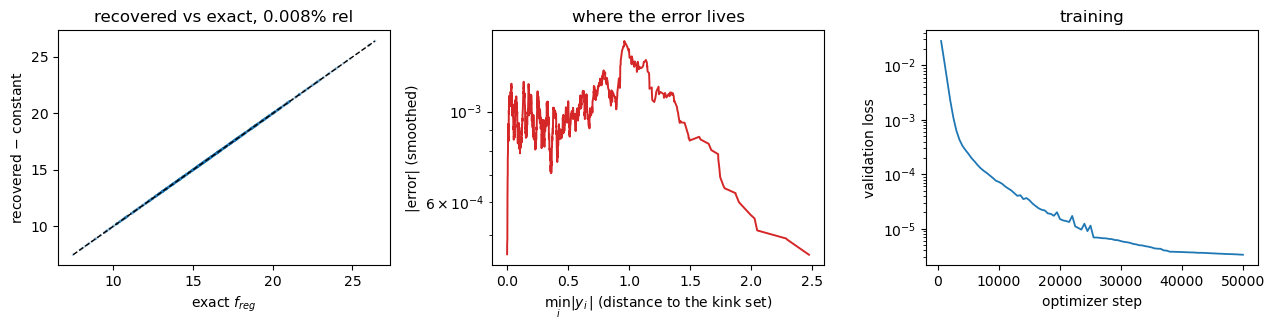

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
lo, hi = freg_eval.min(), freg_eval.max()
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1, zorder=3)
ax[0].scatter(freg_eval, pred - const, s=4, alpha=0.3, color="C0", edgecolors="none")
ax[0].set_xlabel("exact $f_{reg}$"); ax[0].set_ylabel("recovered $-$ constant")
ax[0].set_title(f"recovered vs exact, {rel_c:.3f}% rel")

dist = np.min(np.abs(y_eval), axis=1)             # distance to the kink set
o = np.argsort(dist)
e = np.abs(err - const)[o]
k = max(20, len(e) // 25)
ax[1].plot(dist[o], np.convolve(e, np.ones(k) / k, mode="same"), color="C3", lw=1.4)
ax[1].set_yscale("log"); ax[1].set_xlabel(r"$\min_i |y_i|$ (distance to the kink set)")
ax[1].set_ylabel("|error| (smoothed)"); ax[1].set_title("where the error lives")

ax[2].plot(hist["steps"], hist["val"], color="C0", lw=1.3)
ax[2].set_yscale("log"); ax[2].set_xlabel("optimizer step")
ax[2].set_ylabel("validation loss"); ax[2].set_title("training")
fig.tight_layout(); plt.show()

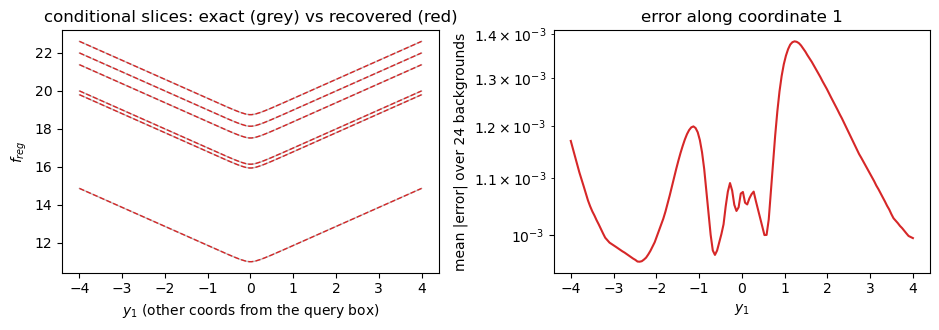

In [7]:
# Conditional slice: coordinate 1 varies, the other n-1 are drawn from the QUERY box.
# An axis slice through the origin would lie -- at n=8 it lives in a volume fraction
# no training point is near (numerics_audit.tex; the D2 plot bug was exactly this).
rng = np.random.default_rng(11)
n_bg, n_g = 24, 160
grid = np.linspace(-A, A, n_g)
pts = np.repeat(rng.uniform(-A, A, (n_bg, DIM)), n_g, axis=0)
pts[:, 0] = np.tile(grid, n_bg)
truth = problem.prior_true(pts).reshape(n_bg, n_g)
pred_s = (net_value(pts) - const).reshape(n_bg, n_g)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
for i in range(0, n_bg, 4):
    ax[0].plot(grid, truth[i], color="0.75", lw=1)
    ax[0].plot(grid, pred_s[i], color="C3", lw=1, ls="--")
ax[0].set_xlabel("$y_1$ (other coords from the query box)"); ax[0].set_ylabel("$f_{reg}$")
ax[0].set_title("conditional slices: exact (grey) vs recovered (red)")
ax[1].plot(grid, np.mean(np.abs(pred_s - truth), axis=0), color="C3", lw=1.5)
ax[1].set_yscale("log"); ax[1].set_xlabel("$y_1$")
ax[1].set_ylabel("mean |error| over 24 backgrounds"); ax[1].set_title("error along coordinate 1")
fig.tight_layout(); plt.show()

## Rerunning

Re-executing the notebook reruns the experiment (~4 min on CPU). Raise `N`, `WIDTH`, `STEPS` toward the
D2 column for production fidelity; runs above $n=8$ are opt-in by project policy, so `DIM` needs a
decision, not an edit.

Ground truth is pinned separately, and must pass before anything here is believed:

```
~/miniforge3/envs/lpn_env/bin/python tests/test_posterior_mean_l1.py
```